# 11 Analiza wrażliwości targetu

Ten notebook sprawdza, czy wnioski dla głównego targetu `drop_10` są stabilne przy zmianie horyzontu predykcji, progu spadku BWCI oraz sposobu etykietowania.

Analiza ma charakter metodologiczny. Nie wybieramy tutaj nowego głównego modelu, tylko sprawdzamy, czy decyzja z notebooków 08-10 jest odporna na rozsądne warianty definicji targetu.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT_CANDIDATES: list[Path] = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if (path / "AGENTS.md").exists()), Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "outputs"
SOURCE_PATH = OUTPUT_DIR / "target_variants_event_threshold_10_v0_1.parquet"
METADATA_PATH = OUTPUT_DIR / "model_dataset_drop_10_v0_1_metadata.json"

SENSITIVITY_VARIANTS_PATH = OUTPUT_DIR / "sensitivity_target_variants_drop_10_v0_1.parquet"
TARGET_SUMMARY_PATH = OUTPUT_DIR / "sensitivity_target_summary_drop_10_v0_1.csv"
TEMPORAL_RESULTS_PATH = OUTPUT_DIR / "sensitivity_temporal_results_drop_10_v0_1.csv"
TEMPORAL_ADVANTAGE_PATH = OUTPUT_DIR / "sensitivity_temporal_advantage_drop_10_v0_1.csv"
LOGO_RESULTS_PATH = OUTPUT_DIR / "sensitivity_logo_results_drop_10_v0_1.csv"
LOGO_SUMMARY_PATH = OUTPUT_DIR / "sensitivity_logo_summary_drop_10_v0_1.csv"
LOGO_ADVANTAGE_PATH = OUTPUT_DIR / "sensitivity_logo_advantage_drop_10_v0_1.csv"
DECISION_PATH = OUTPUT_DIR / "sensitivity_decision_drop_10_v0_1.json"

MAIN_TARGET = "drop_h10_t15"
REFERENCE_TARGET = "drop_10"
RANDOM_STATE = 42
THRESHOLD = 0.50
RF_TREES = 80

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 160)
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Sekcja 1: Konstrukcja wariantów targetu

Sprawdzamy sześć wariantów:

- `drop_h5_t15`: spadek BWCI o co najmniej 0.15 po 5 obserwacjach,
- `drop_h10_t10`: spadek o co najmniej 0.10 po 10 obserwacjach,
- `drop_h10_t15`: główny target, spadek o co najmniej 0.15 po 10 obserwacjach,
- `drop_h10_t20`: spadek o co najmniej 0.20 po 10 obserwacjach,
- `drop_h15_t15`: spadek o co najmniej 0.15 po 15 obserwacjach,
- `threshold_le_full`: alternatywny target stanu niskiego przyszłego BWCI.

Horyzonty 5, 10 i 15 oznaczają liczbę kolejnych obserwacji. Ponieważ BEHACOM jest agregowany minutowo, odpowiada to w przybliżeniu 5, 10 i 15 minutom, ale w opisie pracy bezpieczniej pisać o obserwacjach.


In [2]:
if not SOURCE_PATH.exists():
  raise FileNotFoundError(f"Missing source target variants: {SOURCE_PATH}")
if not METADATA_PATH.exists():
  raise FileNotFoundError(f"Missing metadata: {METADATA_PATH}")

source_df = pd.read_parquet(SOURCE_PATH).sort_values(["USER", "obs_idx"]).copy()
metadata = json.loads(METADATA_PATH.read_text())
feature_sets: dict[str, list[str]] = metadata["feature_sets"]
behavior_features = feature_sets["behavior_primary"]
baseline_features = feature_sets["baseline_autoregressive"]

sensitivity_df = source_df.copy()
sensitivity_df["drop_h10_t15"] = sensitivity_df[REFERENCE_TARGET].astype(float)
sensitivity_df["drop_h10_t10"] = (sensitivity_df["BWCI_future_delta_10"] <= -0.10).astype(float)
sensitivity_df["drop_h10_t20"] = (sensitivity_df["BWCI_future_delta_10"] <= -0.20).astype(float)

for horizon in [5, 15]:
  future_col = f"BWCI_future_{horizon}_sensitivity"
  delta_col = f"BWCI_delta_{horizon}_sensitivity"
  target_col = f"drop_h{horizon}_t15"
  sensitivity_df[future_col] = sensitivity_df.groupby("USER")["BWCI_pu"].shift(-horizon)
  sensitivity_df[delta_col] = sensitivity_df[future_col] - sensitivity_df["BWCI_pu"]
  sensitivity_df[target_col] = np.where(
    sensitivity_df[future_col].notna(),
    (sensitivity_df[delta_col] <= -0.15).astype(int),
    np.nan,
  )

TARGET_VARIANTS = [
  "drop_h5_t15",
  "drop_h10_t10",
  "drop_h10_t15",
  "drop_h10_t20",
  "drop_h15_t15",
  "threshold_le_full",
]

target_labels: dict[str, str] = {
  "drop_h5_t15": "drop, horizon 5, threshold -0.15",
  "drop_h10_t10": "drop, horizon 10, threshold -0.10",
  "drop_h10_t15": "drop, horizon 10, threshold -0.15",
  "drop_h10_t20": "drop, horizon 10, threshold -0.20",
  "drop_h15_t15": "drop, horizon 15, threshold -0.15",
  "threshold_le_full": "future low BWCI, user-level q25 inclusive",
}

main_consistency = sensitivity_df["drop_h10_t15"].astype(int).equals(sensitivity_df[REFERENCE_TARGET].astype(int))
print(f"Main target exactly matches existing drop_10: {main_consistency}")


Main target exactly matches existing drop_10: True


### Interpretacja konstrukcji wariantów

`drop_h10_t15` jest dokładnie tym samym targetem co dotychczasowe `drop_10`, więc analiza wrażliwości nie zmienia definicji głównej. Warianty `drop_h5_t15` i `drop_h15_t15` służą do sprawdzenia horyzontu, a `drop_h10_t10` i `drop_h10_t20` do sprawdzenia progu spadku.

`threshold_le_full` odpowiada innemu pytaniu: nie pyta o spadek względem bieżącego BWCI, tylko o przyszły niski stan BWCI. Traktujemy go jako sensitivity target, nie jako zamiennik głównego targetu.


## Sekcja 2: Stabilność rozkładów targetu

Najpierw sprawdzamy, czy warianty targetu mają używalne rozkłady klas globalnie, per użytkownik oraz między splitami czasowymi.


In [3]:
def jaccard_positive(reference: pd.Series, candidate: pd.Series) -> float:
  """ Compute Jaccard similarity for positive labels.

    Args:
      reference: Reference binary labels.
      candidate: Candidate binary labels.

    Returns:
      float: Jaccard similarity for positive class.
  """
  ref = reference.astype(int)
  cand = candidate.astype(int)
  intersection = ((ref == 1) & (cand == 1)).sum()
  union = ((ref == 1) | (cand == 1)).sum()
  return float(intersection / union) if union > 0 else np.nan


target_summary_rows: list[dict[str, object]] = []
for target in TARGET_VARIANTS:
  valid = sensitivity_df[target].notna()
  part = sensitivity_df[valid]
  by_user = part.groupby("USER")[target].mean() * 100
  by_split = part.groupby("temporal_split")[target].mean() * 100
  target_summary_rows.append(
    {
      "target": target,
      "description": target_labels[target],
      "rows": len(part),
      "positive_pct": part[target].mean() * 100,
      "min_user_positive_pct": by_user.min(),
      "max_user_positive_pct": by_user.max(),
      "std_user_positive_pct": by_user.std(),
      "split_range_pct": by_split.max() - by_split.min(),
      "jaccard_vs_main": jaccard_positive(part[REFERENCE_TARGET], part[target]),
    }
  )

target_summary = pd.DataFrame(target_summary_rows)
target_summary


,target,description,rows,positive_pct,min_user_positive_pct,max_user_positive_pct,std_user_positive_pct,split_range_pct,jaccard_vs_main
0,drop_h5_t15,"drop, horizon 5, threshold -0.15",75984,8.9506,6.1754,14.6002,2.4244,1.3553,0.3034
1,drop_h10_t10,"drop, horizon 10, threshold -0.10",76039,24.0087,21.6710,28.8037,2.3073,1.5645,0.6552
2,drop_h10_t15,"drop, horizon 10, threshold -0.15",76039,15.7314,12.5674,20.8178,2.8370,2.7061,1.0000
3,drop_h10_t20,"drop, horizon 10, threshold -0.20",76039,10.3670,6.2617,18.6691,3.4689,2.8131,0.6590
4,drop_h15_t15,"drop, horizon 15, threshold -0.15",75874,16.6342,13.7347,19.9180,1.9385,2.5768,0.4273
5,threshold_le_full,"future low BWCI, user-level q25 inclusive",76039,27.8226,24.8406,40.9442,4.7920,4.3716,0.3191


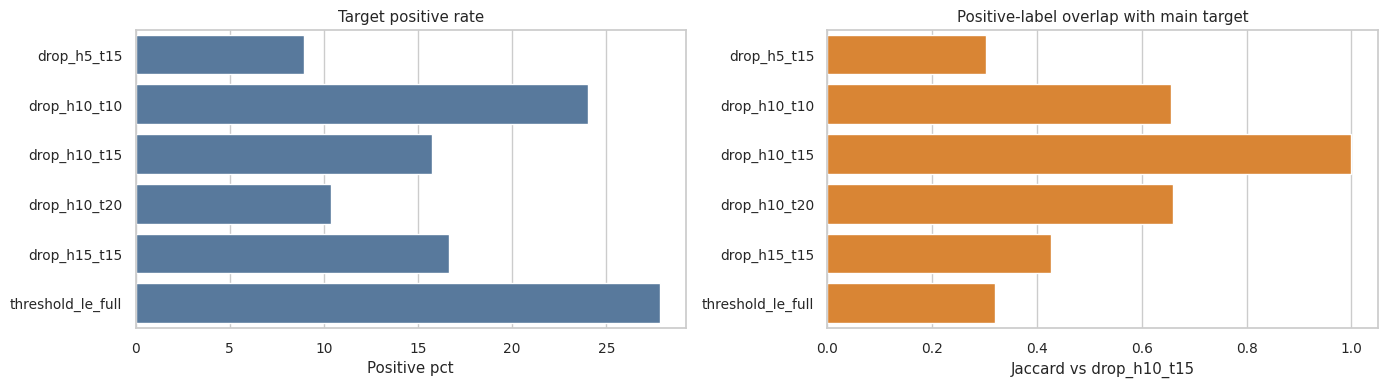

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=target_summary, x="positive_pct", y="target", ax=axes[0], color="#4C78A8")
axes[0].set_title("Target positive rate")
axes[0].set_xlabel("Positive pct")
axes[0].set_ylabel("")

sns.barplot(data=target_summary, x="jaccard_vs_main", y="target", ax=axes[1], color="#F58518")
axes[1].set_title("Positive-label overlap with main target")
axes[1].set_xlabel("Jaccard vs drop_h10_t15")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


### Interpretacja rozkładów targetu

Najrzadszy wariant to `drop_h5_t15`, z 8.95% pozytywów. Najczęstszy jest `threshold_le_full`, z 27.82% pozytywów, a główny `drop_h10_t15` ma 15.73%. Wszystkie warianty są używalne modelowo, ale różnią się częstością zdarzeń, więc AUC-PR trzeba zawsze interpretować względem baseline'u dummy.

Zmiana progu przy horyzoncie 10 działa zgodnie z oczekiwaniem: próg -0.10 daje 24.01% pozytywów, próg -0.15 daje 15.73%, a próg -0.20 daje 10.37%. `drop_h15_t15` ma podobną częstość do głównego targetu, 16.63%, ale tylko Jaccard 0.4273 względem `drop_h10_t15`, więc dłuższy horyzont nie wybiera dokładnie tych samych epizodów.

`threshold_le_full` ma Jaccard 0.3191 względem głównego targetu. To potwierdza, że target stanu niskiego BWCI i target spadku BWCI odpowiadają na różne pytania badawcze.


## Sekcja 3: Temporal split dla wariantów targetu

Porównujemy trzy modele: `dummy_prior`, `autoregressive_lr` oraz `behavior_random_forest`. Random Forest w sensitivity używa tej samej struktury co model główny, ale 80 drzew zamiast 120, żeby utrzymać powtarzalne porównanie wielu wariantów w rozsądnym czasie. Wnioski dotyczą więc wzorca stabilności, a nie ostatecznego benchmarku hiperparametrów.


In [5]:
def make_scaled_logistic_pipeline(class_weight: str | None = "balanced") -> Pipeline:
  """ Create a median-imputed, scaled logistic regression pipeline.

    Args:
      class_weight: Class weighting strategy passed to LogisticRegression.

    Returns:
      Pipeline: Scikit-learn logistic regression pipeline.
  """
  return Pipeline(
    steps=[
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      ("model", LogisticRegression(max_iter=1000, class_weight=class_weight, random_state=RANDOM_STATE, solver="lbfgs")),
    ]
  )


def make_rf_pipeline() -> Pipeline:
  """ Create the sensitivity Random Forest pipeline.

    Returns:
      Pipeline: Median-imputed Random Forest classifier.
  """
  return Pipeline(
    steps=[
      ("imputer", SimpleImputer(strategy="median")),
      (
        "model",
        RandomForestClassifier(
          n_estimators=RF_TREES,
          min_samples_leaf=50,
          class_weight="balanced_subsample",
          n_jobs=-1,
          random_state=RANDOM_STATE,
        ),
      ),
    ]
  )


models: dict[str, tuple[BaseEstimator, list[str], str]] = {
  "dummy_prior": (DummyClassifier(strategy="prior"), baseline_features, "baseline"),
  "autoregressive_lr": (make_scaled_logistic_pipeline(), baseline_features, "baseline"),
  "behavior_random_forest": (make_rf_pipeline(), behavior_features, "primary"),
}


def score_predictions(y_true: pd.Series, y_proba: np.ndarray) -> dict[str, float]:
  """ Score probabilistic binary predictions.

    Args:
      y_true: Binary labels.
      y_proba: Positive-class probabilities.

    Returns:
      dict[str, float]: Metric dictionary.
  """
  y_arr = np.asarray(y_true).astype(int)
  return {
    "auc_pr": average_precision_score(y_arr, y_proba) if len(np.unique(y_arr)) == 2 else np.nan,
    "roc_auc": roc_auc_score(y_arr, y_proba) if len(np.unique(y_arr)) == 2 else np.nan,
    "brier": brier_score_loss(y_arr, y_proba),
  }


In [6]:
temporal_rows: list[dict[str, object]] = []
for target in TARGET_VARIANTS:
  part = sensitivity_df[sensitivity_df[target].notna()].copy()
  part[target] = part[target].astype(int)
  train_part = part[part["temporal_split"] == "train"]
  test_part = part[part["temporal_split"] == "test"]
  for model_name, (model, model_features, group) in models.items():
    fitted = clone(model)
    fitted.fit(train_part[model_features], train_part[target])
    y_proba = fitted.predict_proba(test_part[model_features])[:, 1]
    temporal_rows.append(
      {
        "target": target,
        "description": target_labels[target],
        "model": model_name,
        "model_group": group,
        "evaluation": "temporal_test",
        "rows_test": len(test_part),
        "positive_pct_test": test_part[target].mean() * 100,
        **score_predictions(test_part[target], y_proba),
      }
    )

temporal_results = pd.DataFrame(temporal_rows)
temporal_results.sort_values(["target", "auc_pr"], ascending=[True, False])


,target,description,model,model_group,evaluation,rows_test,positive_pct_test,auc_pr,roc_auc,brier
5,drop_h10_t10,"drop, horizon 10, threshold -0.10",behavior_random_forest,primary,temporal_test,15212,23.7773,0.5078,0.7985,0.1788
4,drop_h10_t10,"drop, horizon 10, threshold -0.10",autoregressive_lr,baseline,temporal_test,15212,23.7773,0.4859,0.7998,0.1852
3,drop_h10_t10,"drop, horizon 10, threshold -0.10",dummy_prior,baseline,temporal_test,15212,23.7773,0.2378,0.5000,0.1812
8,drop_h10_t15,"drop, horizon 10, threshold -0.15",behavior_random_forest,primary,temporal_test,15212,15.9348,0.4143,0.8234,0.1614
7,drop_h10_t15,"drop, horizon 10, threshold -0.15",autoregressive_lr,baseline,temporal_test,15212,15.9348,0.3689,0.8126,0.1820
6,drop_h10_t15,"drop, horizon 10, threshold -0.15",dummy_prior,baseline,temporal_test,15212,15.9348,0.1593,0.5000,0.1340
11,drop_h10_t20,"drop, horizon 10, threshold -0.20",behavior_random_forest,primary,temporal_test,15212,10.7152,0.3828,0.8532,0.1382
10,drop_h10_t20,"drop, horizon 10, threshold -0.20",autoregressive_lr,baseline,temporal_test,15212,10.7152,0.2586,0.8106,0.1836
9,drop_h10_t20,"drop, horizon 10, threshold -0.20",dummy_prior,baseline,temporal_test,15212,10.7152,0.1072,0.5000,0.0958
14,drop_h15_t15,"drop, horizon 15, threshold -0.15",behavior_random_forest,primary,temporal_test,15047,16.8539,0.4340,0.8235,0.1623


In [7]:
def summarize_advantage(results: pd.DataFrame, metric_col: str = "auc_pr") -> pd.DataFrame:
  """ Summarize Random Forest advantage over baselines.

    Args:
      results: Model result table.
      metric_col: Metric used to compute advantage.

    Returns:
      pd.DataFrame: Advantage summary per target.
  """
  rows: list[dict[str, object]] = []
  for target, part in results.groupby("target"):
    lookup = part.set_index("model")
    rows.append(
      {
        "target": target,
        "description": target_labels[target],
        "positive_pct": lookup.loc["behavior_random_forest", "positive_pct_test"],
        "rf_auc_pr": lookup.loc["behavior_random_forest", metric_col],
        "dummy_auc_pr": lookup.loc["dummy_prior", metric_col],
        "autoregressive_auc_pr": lookup.loc["autoregressive_lr", metric_col],
        "delta_vs_dummy": lookup.loc["behavior_random_forest", metric_col] - lookup.loc["dummy_prior", metric_col],
        "delta_vs_autoregressive": lookup.loc["behavior_random_forest", metric_col] - lookup.loc["autoregressive_lr", metric_col],
      }
    )
  return pd.DataFrame(rows)


temporal_advantage = summarize_advantage(temporal_results).sort_values("target").reset_index(drop=True)
temporal_advantage


,target,description,positive_pct,rf_auc_pr,dummy_auc_pr,autoregressive_auc_pr,delta_vs_dummy,delta_vs_autoregressive
0,drop_h10_t10,"drop, horizon 10, threshold -0.10",23.7773,0.5078,0.2378,0.4859,0.2700,0.0219
1,drop_h10_t15,"drop, horizon 10, threshold -0.15",15.9348,0.4143,0.1593,0.3689,0.2549,0.0453
2,drop_h10_t20,"drop, horizon 10, threshold -0.20",10.7152,0.3828,0.1072,0.2586,0.2757,0.1242
3,drop_h15_t15,"drop, horizon 15, threshold -0.15",16.8539,0.4340,0.1685,0.4119,0.2655,0.0222
4,drop_h5_t15,"drop, horizon 5, threshold -0.15",9.0453,0.3145,0.0905,0.1787,0.2241,0.1358
5,threshold_le_full,"future low BWCI, user-level q25 inclusive",30.8901,0.4759,0.3089,0.4342,0.1670,0.0417


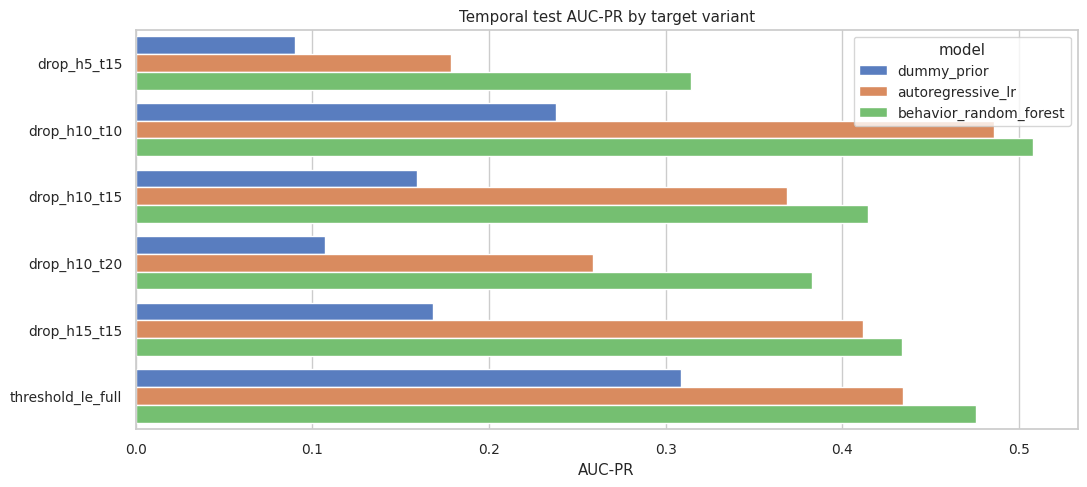

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = temporal_results[temporal_results["model"].isin(["dummy_prior", "autoregressive_lr", "behavior_random_forest"])]
sns.barplot(data=plot_df, x="auc_pr", y="target", hue="model", ax=ax)
ax.set_title("Temporal test AUC-PR by target variant")
ax.set_xlabel("AUC-PR")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Interpretacja temporal split

W temporal split Random Forest bije dummy baseline dla wszystkich wariantów targetu. Przewaga względem dummy mieści się od 0.1670 dla `threshold_le_full` do 0.2762 dla `drop_h10_t20`.

Względem autoregresji Random Forest też jest dodatni we wszystkich wariantach, ale wielkość przewagi zależy od definicji targetu. Dla głównego `drop_h10_t15` przewaga wynosi 0.0453 AUC-PR, dla krótkiego `drop_h5_t15` 0.1358, a dla ostrego progu `drop_h10_t20` 0.1242. Najsłabsza przewaga jest przy łagodnym progu `drop_h10_t10`, 0.0219, oraz dłuższym horyzoncie `drop_h15_t15`, 0.0222.

Wniosek temporalny jest korzystny dla modelu behawioralnego: niezależnie od wariantu targetu cechy telemetryczne dodają informację ponad sam bieżący BWCI, choć siła tego dodatku nie jest stała.


## Sekcja 4: LOGO dla wariantów targetu

LOGO sprawdza, czy wyniki przenoszą się na użytkownika niewidzianego w treningu. To jest najtrudniejszy test i główny sprawdzian ograniczenia personalizacji.


In [9]:
logo_rows: list[dict[str, object]] = []
for target in TARGET_VARIANTS:
  part = sensitivity_df[sensitivity_df[target].notna()].copy()
  part[target] = part[target].astype(int)
  for test_user in sorted(part["USER"].unique()):
    train_part = part[part["USER"] != test_user]
    test_part = part[part["USER"] == test_user]
    for model_name, (model, model_features, group) in models.items():
      fitted = clone(model)
      fitted.fit(train_part[model_features], train_part[target])
      y_proba = fitted.predict_proba(test_part[model_features])[:, 1]
      logo_rows.append(
        {
          "target": target,
          "description": target_labels[target],
          "model": model_name,
          "model_group": group,
          "test_user": int(test_user),
          "rows_test": len(test_part),
          "positive_pct_test": test_part[target].mean() * 100,
          **score_predictions(test_part[target], y_proba),
        }
      )

logo_results = pd.DataFrame(logo_rows)
logo_results.head()


,target,description,model,model_group,test_user,rows_test,positive_pct_test,auc_pr,roc_auc,brier
0,drop_h5_t15,"drop, horizon 5, threshold -0.15",dummy_prior,baseline,0,5306,7.0298,0.0703,0.5000,0.0658
1,drop_h5_t15,"drop, horizon 5, threshold -0.15",autoregressive_lr,baseline,0,5306,7.0298,0.1304,0.7007,0.2190
2,drop_h5_t15,"drop, horizon 5, threshold -0.15",behavior_random_forest,primary,0,5306,7.0298,0.1909,0.7760,0.1273
3,drop_h5_t15,"drop, horizon 5, threshold -0.15",dummy_prior,baseline,1,13445,14.6002,0.1460,0.5000,0.1294
4,drop_h5_t15,"drop, horizon 5, threshold -0.15",autoregressive_lr,baseline,1,13445,14.6002,0.2480,0.7198,0.2073


In [10]:
logo_summary = (
  logo_results
  .groupby(["target", "description", "model", "model_group"])
  .agg(
    auc_pr_macro=("auc_pr", "mean"),
    roc_auc_macro=("roc_auc", "mean"),
    brier_macro=("brier", "mean"),
    positive_pct_macro=("positive_pct_test", "mean"),
    folds=("test_user", "nunique"),
  )
  .reset_index()
)

logo_advantage_rows: list[dict[str, object]] = []
for target, part in logo_summary.groupby("target"):
  lookup = part.set_index("model")
  logo_advantage_rows.append(
    {
      "target": target,
      "description": target_labels[target],
      "rf_auc_pr_macro": lookup.loc["behavior_random_forest", "auc_pr_macro"],
      "dummy_auc_pr_macro": lookup.loc["dummy_prior", "auc_pr_macro"],
      "autoregressive_auc_pr_macro": lookup.loc["autoregressive_lr", "auc_pr_macro"],
      "delta_vs_dummy": lookup.loc["behavior_random_forest", "auc_pr_macro"] - lookup.loc["dummy_prior", "auc_pr_macro"],
      "delta_vs_autoregressive": (
        lookup.loc["behavior_random_forest", "auc_pr_macro"] - lookup.loc["autoregressive_lr", "auc_pr_macro"]
      ),
    }
  )

logo_advantage = pd.DataFrame(logo_advantage_rows).sort_values("target").reset_index(drop=True)
display(logo_summary.sort_values(["target", "auc_pr_macro"], ascending=[True, False]))
display(logo_advantage)


,target,description,model,model_group,auc_pr_macro,roc_auc_macro,brier_macro,positive_pct_macro,folds
0,drop_h10_t10,"drop, horizon 10, threshold -0.10",autoregressive_lr,baseline,0.5103,0.7883,0.1909,23.8682,11
1,drop_h10_t10,"drop, horizon 10, threshold -0.10",behavior_random_forest,primary,0.4361,0.7263,0.2049,23.8682,11
2,drop_h10_t10,"drop, horizon 10, threshold -0.10",dummy_prior,baseline,0.2387,0.5000,0.1818,23.8682,11
3,drop_h10_t15,"drop, horizon 10, threshold -0.15",autoregressive_lr,baseline,0.4033,0.8066,0.1866,15.5557,11
4,drop_h10_t15,"drop, horizon 10, threshold -0.15",behavior_random_forest,primary,0.3371,0.7500,0.1794,15.5557,11
5,drop_h10_t15,"drop, horizon 10, threshold -0.15",dummy_prior,baseline,0.1556,0.5000,0.1315,15.5557,11
6,drop_h10_t20,"drop, horizon 10, threshold -0.20",autoregressive_lr,baseline,0.3026,0.8238,0.1869,9.7721,11
7,drop_h10_t20,"drop, horizon 10, threshold -0.20",behavior_random_forest,primary,0.2369,0.7603,0.1486,9.7721,11
8,drop_h10_t20,"drop, horizon 10, threshold -0.20",dummy_prior,baseline,0.0977,0.5000,0.0886,9.7721,11
9,drop_h15_t15,"drop, horizon 15, threshold -0.15",autoregressive_lr,baseline,0.4551,0.8174,0.1808,16.6583,11


,target,description,rf_auc_pr_macro,dummy_auc_pr_macro,autoregressive_auc_pr_macro,delta_vs_dummy,delta_vs_autoregressive
0,drop_h10_t10,"drop, horizon 10, threshold -0.10",0.4361,0.2387,0.5103,0.1974,-0.0742
1,drop_h10_t15,"drop, horizon 10, threshold -0.15",0.3371,0.1556,0.4033,0.1815,-0.0663
2,drop_h10_t20,"drop, horizon 10, threshold -0.20",0.2369,0.0977,0.3026,0.1391,-0.0658
3,drop_h15_t15,"drop, horizon 15, threshold -0.15",0.3702,0.1666,0.4551,0.2036,-0.0849
4,drop_h5_t15,"drop, horizon 5, threshold -0.15",0.2124,0.0840,0.1793,0.1284,0.0331
5,threshold_le_full,"future low BWCI, user-level q25 inclusive",0.3847,0.2651,0.3886,0.1196,-0.0039


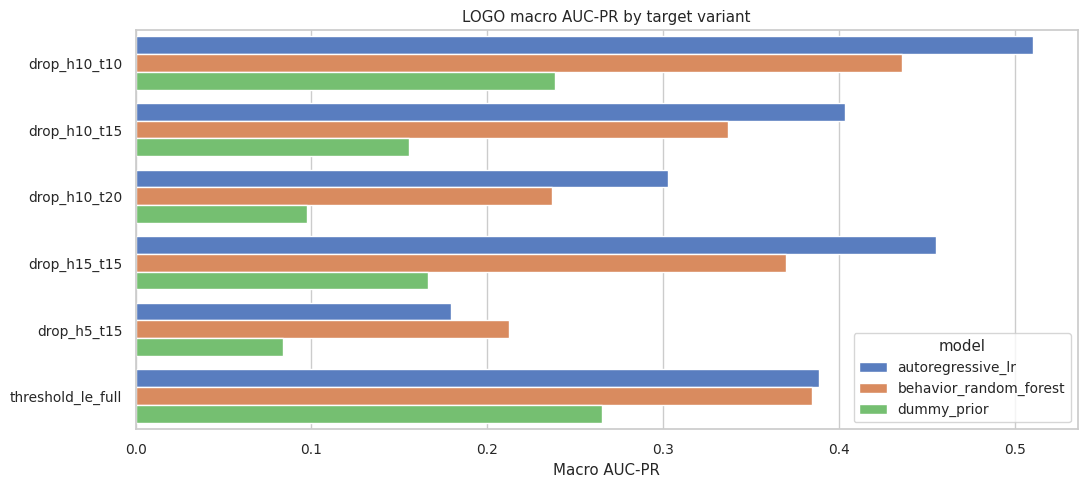

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=logo_summary, x="auc_pr_macro", y="target", hue="model", ax=ax)
ax.set_title("LOGO macro AUC-PR by target variant")
ax.set_xlabel("Macro AUC-PR")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Interpretacja LOGO

LOGO potwierdza główne ograniczenie z notebooka 09. Random Forest bije dummy baseline dla wszystkich wariantów, ale zwykle przegrywa z autoregresją. Dla głównego `drop_h10_t15` wynik RF wynosi około 0.335 macro AUC-PR, a autoregresja około 0.402-0.403.

Najlepszy względny wynik RF względem autoregresji pojawia się dla `drop_h5_t15`, gdzie RF jest wyżej o około 0.033 AUC-PR. Dla `threshold_le_full` różnica względem autoregresji jest bardzo mała, około -0.004. Dla horyzontu 10 i 15 autoregresja pozostaje wyraźnie mocniejsza.

Wniosek jest stabilny: globalny model behawioralny jest użyteczny, ale nowy użytkownik wymaga ostrożności. W dalszej pracy warto sprawdzić modele sekwencyjne i warianty personalizacji, bo sam tablicowy model globalny nie rozwiązuje problemu transferu między użytkownikami.


## Sekcja 5: Decyzja metodologiczna

Łączymy wyniki rozkładu targetów, temporal split i LOGO w jedną decyzję dla dalszych etapów.


In [12]:
sensitivity_decision: dict[str, object] = {
  "primary_target": "drop_10 / drop_h10_t15",
  "primary_target_status": "kept as the main target",
  "main_reason": (
    "The target has a usable positive rate, stable enough per-user distribution, and a clear behavioral interpretation as a future BWCI drop."
  ),
  "temporal_conclusion": (
    "Random Forest beats dummy and autoregressive baselines across tested target variants in temporal split."
  ),
  "logo_conclusion": (
    "Random Forest beats dummy across variants but usually does not beat the autoregressive BWCI baseline under LOGO."
  ),
  "sensitivity_target_to_report": "threshold_le_full",
  "sequential_models_recommended": True,
  "personalization_recommended": True,
}

sensitivity_decision


{'primary_target': 'drop_10 / drop_h10_t15',
 'primary_target_status': 'kept as the main target',
 'main_reason': 'The target has a usable positive rate, stable enough per-user distribution, and a clear behavioral interpretation as a future BWCI drop.',
 'temporal_conclusion': 'Random Forest beats dummy and autoregressive baselines across tested target variants in temporal split.',
 'logo_conclusion': 'Random Forest beats dummy across variants but usually does not beat the autoregressive BWCI baseline under LOGO.',
 'sensitivity_target_to_report': 'threshold_le_full',
 'sequential_models_recommended': True,
 'personalization_recommended': True}

### Decyzja po analizie wrażliwości

Zostawiamy `drop_10`, czyli `drop_h10_t15`, jako główny target. Ma 15.73% pozytywów, stabilniejszy rozkład per użytkownik niż poprzedni `event_threshold_10` i bezpośrednio odpowiada tematowi pracy: ryzyko pogorszenia ciągłości pracy w krótkim horyzoncie.

Do raportowania jako sensitivity warto zachować `threshold_le_full`, bo odpowiada na inne pytanie: przyszły niski poziom BWCI zamiast spadku względem bieżącego stanu. Wyniki dla tego wariantu są słabszym, ale użytecznym testem odporności wniosków.

Najważniejszy wniosek dla dalszej części: problem generalizacji na nowego użytkownika nie znika po zmianie targetu. To uzasadnia kolejny blok pracy nad modelami sekwencyjnymi oraz potencjalnie nad personalizacją.


## Sekcja 6: Zapis artefaktów

Zapisujemy tabele sensitivity, żeby można było wrócić do nich przy pisaniu wyników i przygotowaniu kolejnego bloku eksperymentów.


In [13]:
sensitivity_df.to_parquet(SENSITIVITY_VARIANTS_PATH, index=False)
target_summary.to_csv(TARGET_SUMMARY_PATH, index=False)
temporal_results.to_csv(TEMPORAL_RESULTS_PATH, index=False)
temporal_advantage.to_csv(TEMPORAL_ADVANTAGE_PATH, index=False)
logo_results.to_csv(LOGO_RESULTS_PATH, index=False)
logo_summary.to_csv(LOGO_SUMMARY_PATH, index=False)
logo_advantage.to_csv(LOGO_ADVANTAGE_PATH, index=False)
DECISION_PATH.write_text(json.dumps(sensitivity_decision, indent=2), encoding="utf-8")

print(f"Saved sensitivity variants: {SENSITIVITY_VARIANTS_PATH}")
print(f"Saved target summary: {TARGET_SUMMARY_PATH}")
print(f"Saved temporal results: {TEMPORAL_RESULTS_PATH}")
print(f"Saved temporal advantage: {TEMPORAL_ADVANTAGE_PATH}")
print(f"Saved LOGO results: {LOGO_RESULTS_PATH}")
print(f"Saved LOGO summary: {LOGO_SUMMARY_PATH}")
print(f"Saved LOGO advantage: {LOGO_ADVANTAGE_PATH}")
print(f"Saved decision: {DECISION_PATH}")


Saved sensitivity variants: /home/sefni/git/bwci-thesis/outputs/sensitivity_target_variants_drop_10_v0_1.parquet
Saved target summary: /home/sefni/git/bwci-thesis/outputs/sensitivity_target_summary_drop_10_v0_1.csv
Saved temporal results: /home/sefni/git/bwci-thesis/outputs/sensitivity_temporal_results_drop_10_v0_1.csv
Saved temporal advantage: /home/sefni/git/bwci-thesis/outputs/sensitivity_temporal_advantage_drop_10_v0_1.csv
Saved LOGO results: /home/sefni/git/bwci-thesis/outputs/sensitivity_logo_results_drop_10_v0_1.csv
Saved LOGO summary: /home/sefni/git/bwci-thesis/outputs/sensitivity_logo_summary_drop_10_v0_1.csv
Saved LOGO advantage: /home/sefni/git/bwci-thesis/outputs/sensitivity_logo_advantage_drop_10_v0_1.csv
Saved decision: /home/sefni/git/bwci-thesis/outputs/sensitivity_decision_drop_10_v0_1.json


## Krótkie sprawozdanie z etapu 11

Etap 11 potwierdza, że wybór `drop_10` jest metodologicznie sensowny. Zmiana progu i horyzontu wpływa na częstość zdarzeń oraz na poziom AUC-PR, ale nie zmienia głównego obrazu: w temporal split cechy behawioralne dodają wartość ponad baseline'y, natomiast w LOGO autoregresyjny baseline pozostaje bardzo silny.

## Wstępny plan dalszych prac

1. **Notebook 12: dataset sekwencyjny dla `drop_10`**

   Przygotować sekwencje ostatnich 10, 20 i 30 obserwacji cech behawioralnych. Target pozostaje `drop_10`. Trzeba jawnie oddzielić wariant temporal split i LOGO, żeby nie wprowadzić leakage między użytkownikami ani przyszłością.

2. **Notebook 13: pierwsze modele sekwencyjne**

   Porównać proste modele sekwencyjne z tablicowym Random Forest i autoregresją. Minimalny zestaw: 1D-CNN lub TCN oraz GRU/LSTM. Główne pytanie: czy sekwencja surowych obserwacji daje poprawę względem cech okienkowych.

3. **Notebook 14: walidacja i porównanie końcowe modeli**

   Zestawić modele tablicowe i sekwencyjne w jednej tabeli: temporal split, LOGO, AUC-PR, AUC-ROC, Brier, precision, recall oraz wyniki per użytkownik. Na tym etapie trzeba zdecydować, który model jest głównym modelem pracy, a który pozostaje rozszerzeniem.

4. **Notebook 15: personalizacja lub adaptacja użytkownika**

   Sprawdzić prosty wariant personalizacji, na przykład model globalny z kalibracją per user, trening na części historii użytkownika albo porównanie global vs user-specific dla użytkowników z wystarczającą liczbą danych.

5. **Notebook 16: syntetyczne podsumowanie wyników do pracy**

   Zebrać finalne tabele, wykresy i wnioski metodologiczne: konstrukcja BWCI, wybór targetu, porównanie modeli, ograniczenia LOGO, interpretacja cech oraz plan walidacji zewnętrznej lub demonstratora.
